In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("mymoviedb.csv" , lineterminator='\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


things we need to do 
1) change the dtype of release date to date time
2) remove cols overview,poster url,og language
3) remove gaps

In [15]:
df['Release_Date']=pd.to_datetime(df['Release_Date'],dayfirst='True',errors='coerce')
print(df['Release_Date'].dtype)

datetime64[us]


In [16]:
df[	'Release_Date']

0      2021-12-15
1      2022-03-01
2      2022-02-25
3      2021-11-24
4      2021-12-22
          ...    
9832   1973-10-15
9833   2020-10-01
9834   2016-05-06
9835   2021-03-31
9836   1984-09-23
Name: Release_Date, Length: 9837, dtype: datetime64[us]

In [17]:
df[	'Release_Date']=df[	'Release_Date'].dt.year

In [18]:
df[	'Release_Date']

0       2021.0
1       2022.0
2       2022.0
3       2021.0
4       2021.0
         ...  
9832    1973.0
9833    2020.0
9834    2016.0
9835    2021.0
9836    1984.0
Name: Release_Date, Length: 9837, dtype: float64

In [37]:
cols=['Overview', 'Original_Language' , 'Poster_Url\r']

In [38]:
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [39]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7,"Action, Adventure, Thriller, War"


In [40]:
df1=df.copy()

In [41]:
df1


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973.0,Badlands,13.357,896,7.6,"Drama, Crime"
9833,2020.0,Violent Delights,13.356,8,3.5,Horror
9834,2016.0,The Offering,13.355,94,5,"Mystery, Thriller, Horror"
9835,2021.0,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History"


In [52]:
#WE WILL DESCRIBE MOVIES AS POPULAR, AVERAGE, BELOW_AVERAGE, NOT_POPULAR
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')


In [53]:
def categorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df
        

In [54]:
labels=['NOT_POPULAR', 'BELOW_AVERAGE','AVERAGE','POPULAR',]
categorize_col(df, 'Vote_Average' ,labels)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,POPULAR,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,BELOW_AVERAGE,Thriller
3,2021.0,Encanto,2402.201,5076,POPULAR,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,AVERAGE,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973.0,Badlands,13.357,896,POPULAR,"Drama, Crime"
9833,2020.0,Violent Delights,13.356,8,NOT_POPULAR,Horror
9834,2016.0,The Offering,13.355,94,NOT_POPULAR,"Mystery, Thriller, Horror"
9835,2021.0,The United States vs. Billie Holiday,13.354,152,AVERAGE,"Music, Drama, History"


In [55]:
df1=df.copy()

In [58]:
df1

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,POPULAR,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,BELOW_AVERAGE,Thriller
3,2021.0,Encanto,2402.201,5076,POPULAR,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,AVERAGE,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9832,1973.0,Badlands,13.357,896,POPULAR,"Drama, Crime"
9833,2020.0,Violent Delights,13.356,8,NOT_POPULAR,Horror
9834,2016.0,The Offering,13.355,94,NOT_POPULAR,"Mystery, Thriller, Horror"
9835,2021.0,The United States vs. Billie Holiday,13.354,152,AVERAGE,"Music, Drama, History"


In [57]:
df['Vote_Average'].value_counts()

Vote_Average
NOT_POPULAR      2467
POPULAR          2450
AVERAGE          2411
BELOW_AVERAGE    2398
Name: count, dtype: int64

In [60]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [61]:
df1=df.copy()

now we will split genere in singlur 

In [73]:
df['Genre']=df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop= True)

In [74]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Science Fiction
3,2022.0,The Batman,3827.658,1151,POPULAR,Crime
4,2022.0,The Batman,3827.658,1151,POPULAR,Mystery


In [75]:
df1=df.copy() 

In [78]:
#casting column into category
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes


CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [80]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [81]:
df.head()  

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Science Fiction
3,2022.0,The Batman,3827.658,1151,POPULAR,Crime
4,2022.0,The Batman,3827.658,1151,POPULAR,Mystery


#  DATA VISUALIZATION

In [83]:
sns.set_style('whitegrid')

# genres which has most frequent movies


In [84]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

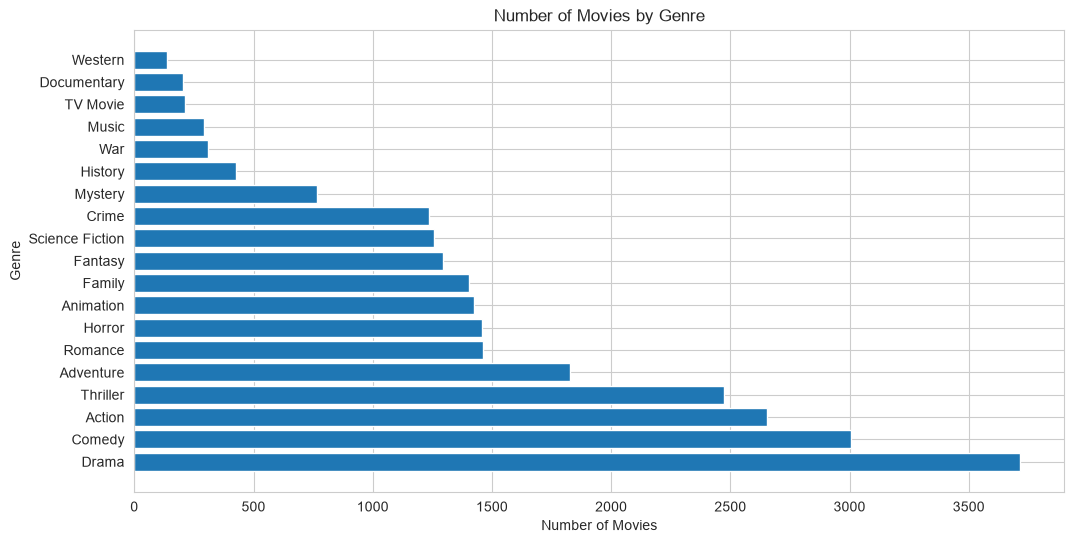

In [88]:
genre_counts = df['Genre'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(genre_counts.index, genre_counts.values)

plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.title('Number of Movies by Genre')

plt.show()

#which has the highest votes in vote average coloumn

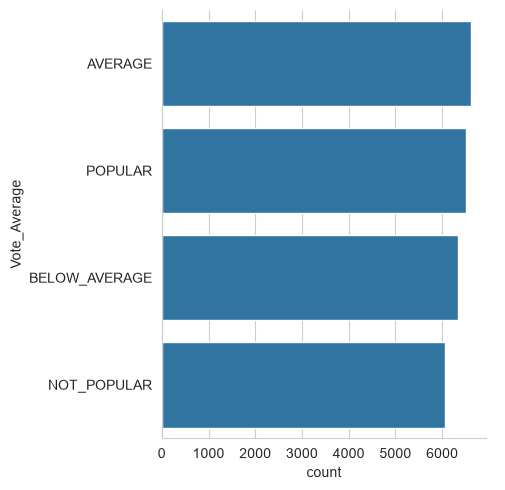

In [96]:
sns.catplot(y='Vote_Average', data=df, kind='count', order=df['Vote_Average'].value_counts().index)


#  most popular movie and its genre

In [99]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,POPULAR,Science Fiction


# least popular movie and its genre

In [101]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021.0,The United States vs. Billie Holiday,13.354,152,AVERAGE,Music
25546,2021.0,The United States vs. Billie Holiday,13.354,152,AVERAGE,Drama
25547,2021.0,The United States vs. Billie Holiday,13.354,152,AVERAGE,History
25548,1984.0,Threads,13.354,186,POPULAR,War
25549,1984.0,Threads,13.354,186,POPULAR,Drama
25550,1984.0,Threads,13.354,186,POPULAR,Science Fiction


# year with the most no of movie releases 

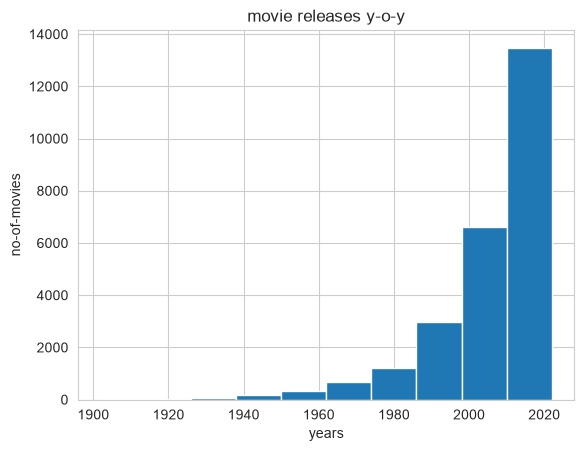

In [103]:
df['Release_Date'].hist()
plt.title('movie releases y-o-y')
plt.xlabel('years')
plt.ylabel('no-of-movies')
plt.show()        
    

In [104]:
df1=df.copy()